# book2genome: k-mer exploration

A worked example of the book2genome analogy, using **English, French, and German** as a
representative subset of the dataset. Each book has been reduced to an uppercase,
letters-only character sequence (see `scripts/preprocess.py`), mirroring how a genome
is a sequence built from a small alphabet (A/C/G/T) rather than words.

We treat short substrings of that sequence &mdash; k-mers &mdash; the same way genomics treats
short DNA motifs, and ask whether their frequencies alone are enough to tell the three
languages apart.

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from itertools import combinations
from scipy.spatial.distance import cosine

languages = ["english", "french", "german"]
colors = {"english": "#4C78A8", "french": "#B45F5F", "german": "#4F8A70"}


## 1. What is a k-mer?

A k-mer is simply every substring of length `k` in a sequence, read with a sliding window.
`k=1` looks at single characters, `k=2` at character pairs, and so on &mdash; the same operation
used to break a DNA sequence into overlapping motifs.

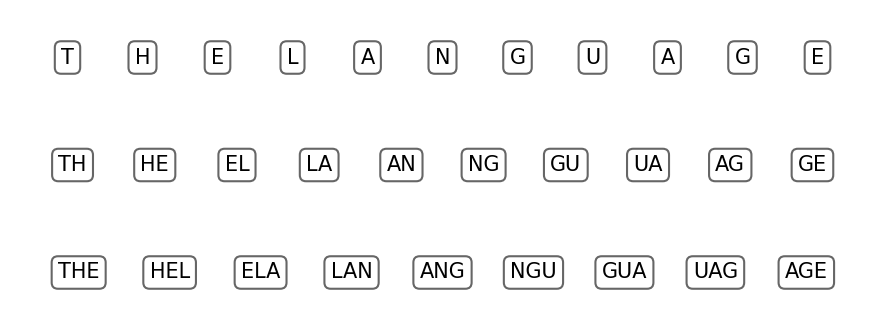

In [2]:
seq = "THELANGUAGE"

fig, axes = plt.subplots(3, 1, figsize=(6, 2.3), dpi=150)

for ax, k in zip(axes, [1, 2, 3]):
    kmers = [seq[i:i+k] for i in range(len(seq) - k + 1)]

    for i, x in enumerate(kmers):
        ax.text(i, 0, x, ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.4"))

    ax.set_xlim(-0.7, len(kmers) - 0.3)
    ax.set_ylim(-0.7, 0.7)
    ax.set_ylabel(f"k = {k}", rotation=0, labelpad=25, va="center")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 2. Load the books

Book metadata and sequence lengths are read from `processed/book/`, the **cleaned**
uppercase-letter sequences produced by `preprocess.py` &mdash; the same files that were fed into
`count_kmers.py`. Using the processed directory (rather than the original raw books) keeps
this notebook portable: it only depends on files already committed to the repo, not on a
machine-specific path to the source book collection.

In [3]:
book_dir = Path("../processed/book")
books = pd.DataFrame([
    {"language": lang, "book": path.stem, "path": path}
    for lang in languages
    for path in sorted((book_dir / lang).glob("*.txt"))
])

display(books)


,language,book,path
0,english,alice,../processed/book/english/alice.txt
1,english,mobydick,../processed/book/english/mobydick.txt
2,english,pride,../processed/book/english/pride.txt
3,english,sherlock,../processed/book/english/sherlock.txt
4,french,candide,../processed/book/french/candide.txt
5,french,madame_bovary,../processed/book/french/madame_bovary.txt
6,french,notre_dame,../processed/book/french/notre_dame.txt
7,german,faust,../processed/book/german/faust.txt
8,german,kafka_verwandlung,../processed/book/german/kafka_verwandlung.txt
9,german,nietzsche_zarathustra,../processed/book/german/nietzsche_zarathustra...


In [4]:
books["n_char"] = books["path"].apply(lambda p: len(p.read_text().strip()))

display(books[["language", "book", "n_char"]])
display(books.groupby("language")["n_char"].agg(["count", "mean", "min", "max"]).round(0))


,language,book,n_char
0,english,alice,108083
1,english,mobydick,955178
2,english,pride,563939
3,english,sherlock,431477
4,french,candide,157609
5,french,madame_bovary,512877
6,french,notre_dame,826234
7,german,faust,148628
8,german,kafka_verwandlung,99225
9,german,nietzsche_zarathustra,410866


,count,mean,min,max
language,,,,
english,4,514669.0,108083,955178
french,3,498907.0,157609,826234
german,3,219573.0,99225,410866


## 3. Load precomputed k-mer counts

`count_kmers.py` already generated frequency tables for k = 1 through 6 in `results/kmers/`.
We load all of them here, and mainly work with k = 1, 2, 3 below.

In [5]:
kmer_dir = Path("../results/kmers")

kmer = {}
for k in range(1, 7):
    kmer[k] = pd.read_csv(kmer_dir / f"k{k}_book_counts.tsv", sep="\t")
    print(f"k={k}: {kmer[k].shape}")

display(kmer[2].head())


k=1: (572, 6)
k=2: (11822, 6)
k=3: (121306, 6)
k=4: (646290, 6)
k=5: (1799938, 6)
k=6: (3249516, 6)


,language,book,k,kmer,count,frequency
0,dutch,camera_obscura,2,PR,398,0.001094
1,dutch,camera_obscura,2,RO,2287,0.006286
2,dutch,camera_obscura,2,OD,709,0.001949
3,dutch,camera_obscura,2,DU,276,0.000759
4,dutch,camera_obscura,2,UC,486,0.001336


## 4. Build a balanced subset

To keep the comparison fair, we use exactly three books per language rather than the full,
uneven collection (English currently has four books; French and German have three each).

In [6]:
keep_books = {
    "english": ["alice", "pride", "sherlock"],
    "french": ["candide", "madame_bovary", "notre_dame"],
    "german": ["faust", "kafka_verwandlung", "nietzsche_zarathustra"],
}

data = {}
for k in [1, 2, 3]:
    df = kmer[k].query("language in @languages").copy()
    data[k] = df[df.apply(lambda x: x["book"] in keep_books[x["language"]], axis=1)]

for k, df in data.items():
    print(f"k={k}: {df['book'].nunique()} books | frequency sum/book:",
          df.groupby(["language", "book"])["frequency"].sum().round(3).unique())


k=1: 9 books | frequency sum/book: [1.]
k=2: 9 books | frequency sum/book: [1.]
k=3: 9 books | frequency sum/book: [1.]


## 5. Most frequent k-mers by language

Before looking for what separates the languages, a sanity check: what are the most common
k-mers within each one? At k = 1 this is essentially letter frequency; longer k should start
to pick up bigrams/trigrams typical of each language.

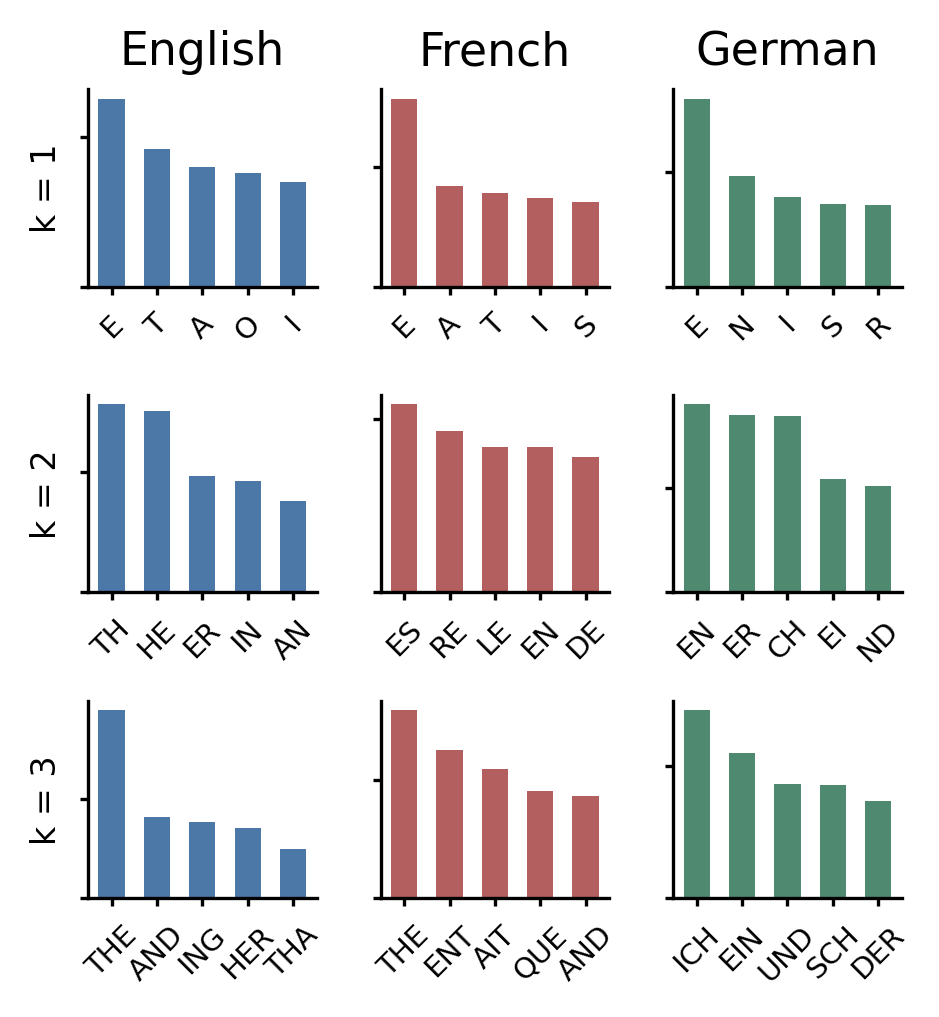

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(3.5, 3.5), dpi=300)

for col, lang in enumerate(languages):
    for row, k in enumerate([1, 2, 3]):
        ax = axes[row, col]
        s = data[k].query("language == @lang").groupby("kmer")["frequency"].mean().nlargest(5)

        ax.bar(s.index, s.values, width=0.58, color=colors[lang])
        ax.tick_params(axis="x", rotation=45, labelsize=7, length=2)
        ax.tick_params(axis="y", labelleft=False, length=2)
        ax.spines[["top", "right"]].set_visible(False)

        if row == 0: ax.set_title(lang.capitalize(), fontsize=11)
        if col == 0: ax.set_ylabel(f"k = {k}", fontsize=8)

fig.subplots_adjust(wspace=0.28, hspace=0.55)
plt.show()


## 6. PCA of language k-mer profiles

Each language's mean k-mer frequencies (k = 1, 2, 3 combined, standardized per k-mer) are
projected into two dimensions with PCA. If sequence composition alone carries a language
signal, the three languages should separate cleanly even with only three points.

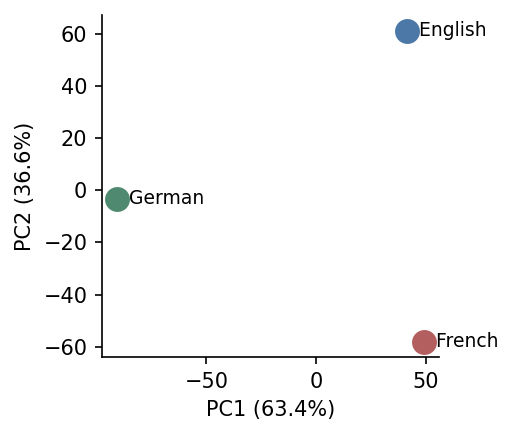

In [17]:
blocks = []

for k in [1, 2, 3]:
    d = data[k].groupby(["language", "kmer"])["frequency"].mean().unstack(fill_value=0)
    d = d.sub(d.mean()).div(d.std().replace(0, 1))
    d.columns = [f"k{k}_{x}" for x in d.columns]
    blocks.append(d)

X_lang = pd.concat(blocks, axis=1).loc[languages]

pca = PCA(n_components=2)
Z = pca.fit_transform(X_lang)

pca_df = pd.DataFrame(Z, index=X_lang.index, columns=["PC1", "PC2"])

fig, ax = plt.subplots(figsize=(3.5, 3), dpi=150)

for lang in languages:
    ax.scatter(pca_df.loc[lang, "PC1"], pca_df.loc[lang, "PC2"],
               s=120, color=colors[lang], label=lang.capitalize())
    ax.text(pca_df.loc[lang, "PC1"], pca_df.loc[lang, "PC2"],
            f"  {lang.capitalize()}", va="center", fontsize=9)

# ax.axhline(0, lw=0.7, color="0.7"); ax.axvline(0, lw=0.7, color="0.7")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.spines[["top", "right"]].set_visible(False)
# ax.legend(frameon=False)

plt.tight_layout()
plt.show()


## 7. What drives the PCA separation

The PCA loadings tell us *which* k-mers contribute most to pulling the languages apart in the
plot above.

In [9]:
loadings = pd.DataFrame({
    "feature": X_lang.columns,
    "PC1": pca.components_[0],
    "PC2": pca.components_[1],
})

loadings["contribution"] = np.sqrt(loadings["PC1"]**2 + loadings["PC2"]**2)
loadings["k"] = loadings["feature"].str.extract(r"k(\d)").astype(int)
loadings["kmer"] = loadings["feature"].str.replace(r"k\d_", "", regex=True)

top = loadings.nlargest(20, "contribution")

display(top[["k", "kmer", "PC1", "PC2", "contribution"]].round(3))


,k,kmer,PC1,PC2,contribution
8462,3,UTT,0.0,0.017,0.017
1197,3,BAM,0.0,-0.017,0.017
8603,3,VIB,0.0,-0.017,0.017
1278,3,BIG,-0.0,-0.017,0.017
152,2,EW,0.0,0.017,0.017
1236,3,BEG,0.0,0.017,0.017
190,2,GJ,-0.0,0.017,0.017
8150,3,UEG,-0.0,-0.017,0.017
9549,3,ZEJ,0.0,-0.017,0.017
7285,3,SAB,-0.0,-0.017,0.017


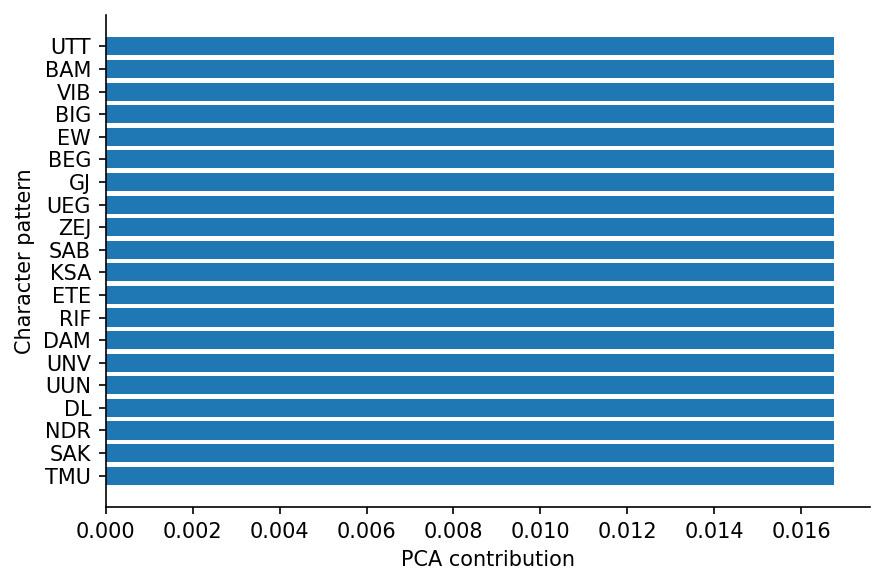

In [10]:
# Top character patterns separating the languages

top = top.sort_values("contribution")

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
ax.barh(top["kmer"], top["contribution"])

ax.set_xlabel("PCA contribution")
ax.set_ylabel("Character pattern")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


## 8. Does separation improve with longer k-mers?

Using cosine distance between each pair of languages' k-mer profiles, we can check whether
longer k-mers (more context) make languages more distinguishable than single characters do.

In [11]:
rows = []

for k in [1, 2, 3]:
    m = data[k].groupby(["language", "kmer"])["frequency"].mean().unstack(fill_value=0)

    for a, b in combinations(languages, 2):
        rows.append([k, a, b, cosine(m.loc[a], m.loc[b])])

separation = pd.DataFrame(
    rows, columns=["k", "language_1", "language_2", "distance"]
)

display(separation)
display(separation.groupby("k")["distance"].mean().rename("Mean distance"))


,k,language_1,language_2,distance
0,1,english,french,0.031131
1,1,english,german,0.058747
2,1,french,german,0.039699
3,2,english,french,0.156860
4,2,english,german,0.349105
5,2,french,german,0.282624
6,3,english,french,0.296734
7,3,english,german,0.672169
8,3,french,german,0.599450


k
1    0.043192
2    0.262863
3    0.522784
Name: Mean distance, dtype: float64

## 9. Language-specific k-mers

For each language and k, we rank k-mers by how much more frequent they are compared to the
*average* of the other languages &mdash; i.e. what's distinctively characteristic of that
language's sequence composition.

In [12]:
specificity = []

for k in [1, 2, 3]:
    m = data[k].groupby(["language", "kmer"])["frequency"].mean().unstack(fill_value=0)

    for lang in languages:
        score = m.loc[lang] - m.drop(lang).mean()
        top = score.nlargest(10)

        specificity.append(pd.DataFrame({
            "language": lang, "k": k,
            "kmer": top.index, "score": top.values
        }))

specificity = pd.concat(specificity, ignore_index=True)

display(specificity)


,language,k,kmer,score
0,english,1,O,0.033691
1,english,1,T,0.023639
2,english,1,H,0.021677
3,english,1,Y,0.018182
4,english,1,W,0.011574
...,...,...,...,...
85,german,3,DER,0.006409
86,german,3,DIE,0.006012
87,german,3,NDE,0.005047
88,german,3,CHE,0.004744


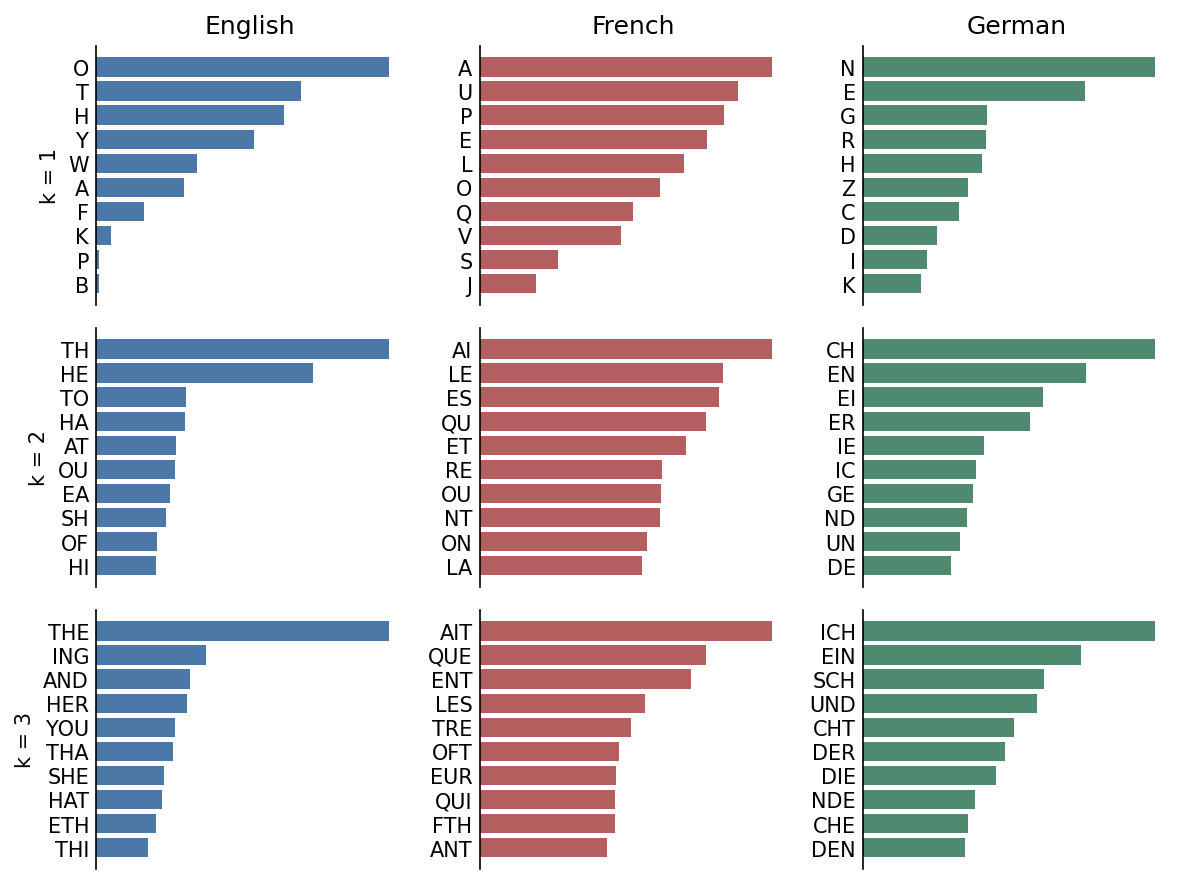

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(8, 6), dpi=150)

for col, lang in enumerate(languages):
    for row, k in enumerate([1, 2, 3]):
        ax = axes[row, col]
        d = specificity.query("language == @lang and k == @k").sort_values("score")

        ax.barh(d["kmer"], d["score"], color=colors[lang])
        ax.set_xticks([])
        ax.tick_params(axis="y", length=0)
        ax.spines[["top", "right", "bottom"]].set_visible(False)

        if row == 0:
            ax.set_title(lang.capitalize(), fontsize=12)
        if col == 0:
            ax.set_ylabel(f"k = {k}")

plt.tight_layout()
plt.show()


## 10. Which k-mer length carries the most signal?

Summing the positive specificity scores per language and k-mer length shows which context size
(single letters, pairs, or triplets) contributes the most discriminative information for each
language.

In [14]:
info = (
    specificity.assign(score_pos=lambda x: x["score"].clip(lower=0))
    .groupby(["language", "k"])["score_pos"].sum()
    .unstack(fill_value=0)
)

info_pct = info.div(info.sum(axis=1), axis=0) * 100
display(info_pct.round(1))


k,1,2,3
language,,,
english,47.4,33.9,18.6
french,48.0,36.7,15.3
german,36.5,42.6,20.9


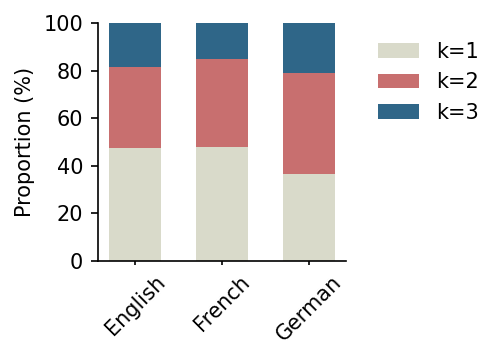

In [15]:
k_colors = {1: "#D9DACA", 2: "#C86F6F", 3: "#2F6688"}

fig, ax = plt.subplots(figsize=(3.5, 2.5), dpi=150)

bottom = np.zeros(len(languages))

for k in [1, 2, 3]:
    values = info_pct.loc[languages, k]

    ax.bar(
        [x.capitalize() for x in languages],
        values,
        bottom=bottom,
        color=k_colors[k],
        width=0.6,
        label=f"k={k}"
    )

    bottom += values.values

ax.set_ylabel("Proportion (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=45, labelsize=10, length=2)
ax.legend(frameon=False, title="Sequence context")

ax.spines[["top", "right"]].set_visible(False)
ax.legend(
    frameon=False,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


## 11. Top distinctive k-mers per language

Finally, for each language's most informative k, here are its five most distinctive k-mers &mdash;
the closest thing in this analogy to a language-specific "sequence motif".

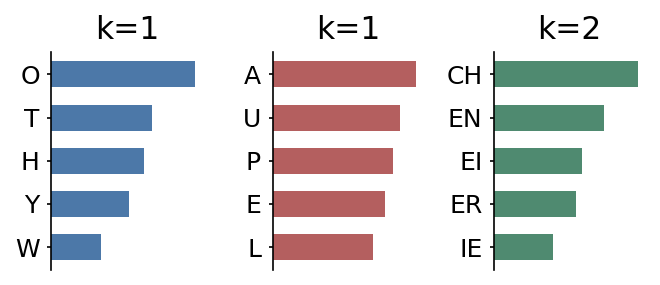

In [16]:
top5 = []

for lang in languages:
    best_k = info_pct.loc[lang].idxmax()
    d = specificity.query("language == @lang and k == @best_k").nlargest(5, "score").copy()
    d["dominant_k"] = best_k
    top5.append(d)

top5 = pd.concat(top5, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(4.5, 2), dpi=150)

for ax, lang in zip(axes, languages):
    d = top5.query("language == @lang").sort_values("score")
    k = d["dominant_k"].iloc[0]

    ax.barh(d["kmer"], d["score"], color=colors[lang], height=0.6)
    ax.set_title(f"k={k}", fontsize=15)
    ax.set_xticks([])
    ax.tick_params(axis="y", labelsize=12, length=2)
    ax.spines[["top", "right", "bottom"]].set_visible(False)

plt.tight_layout()
plt.show()
